In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.

In [1]:
!pip install scikit-surprise --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 7.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554967 sha256=45db40d2e7c68d8949e57a3a95d368218088150eea3e1bcb89935581972f3786
  Stored in directory: /tmp/pip-ephem-wheel-cache-a0ing8yh/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


First 5 rows:
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

Columns:
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
===== Part (c): 5-Fold Cross Validation =====

PMF / Matrix Factorization
Average RMSE: 1.0065
Average MAE : 0.7761
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.

User-Based CF
Average RMSE: 0.9943
Average MAE : 0.7686
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Don

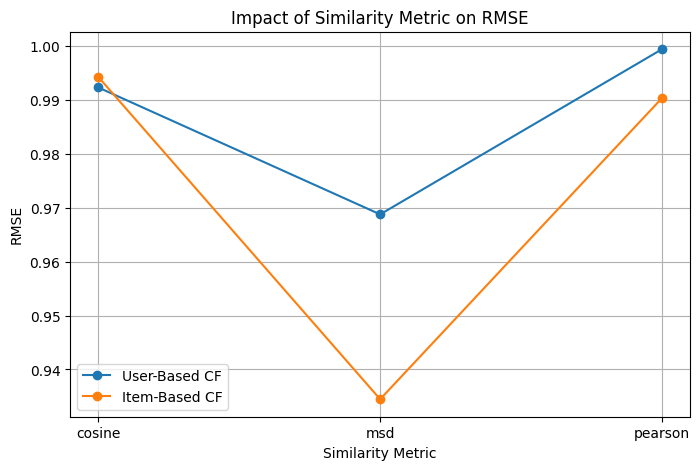

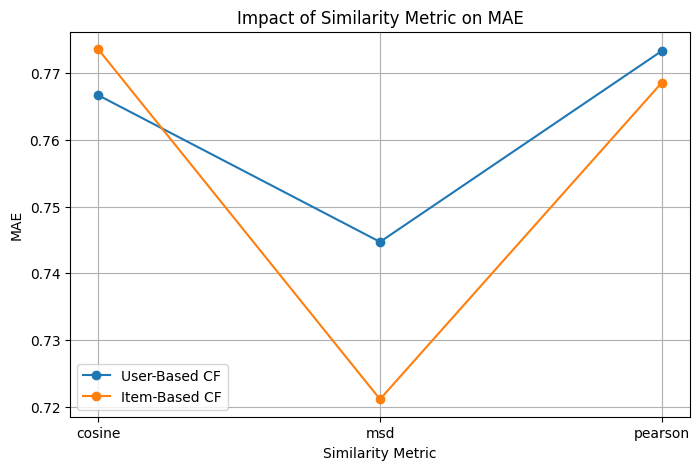


===== Part (f): Number of Neighbors (K) =====
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.

User-Based CF (K=5)
Average RMSE: 1.0425
Average MAE : 0.8046
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.

Item-Based CF (K=5)
Average RMSE: 1.1015
Average MAE : 0.8592
Computing the cosine similarity matrix...
Done computing similarity

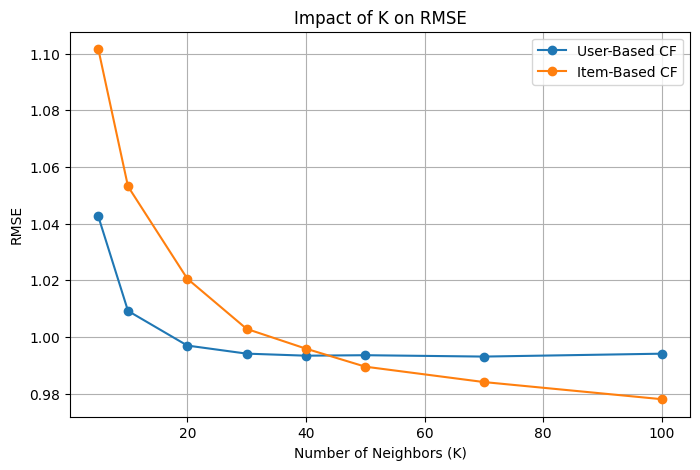

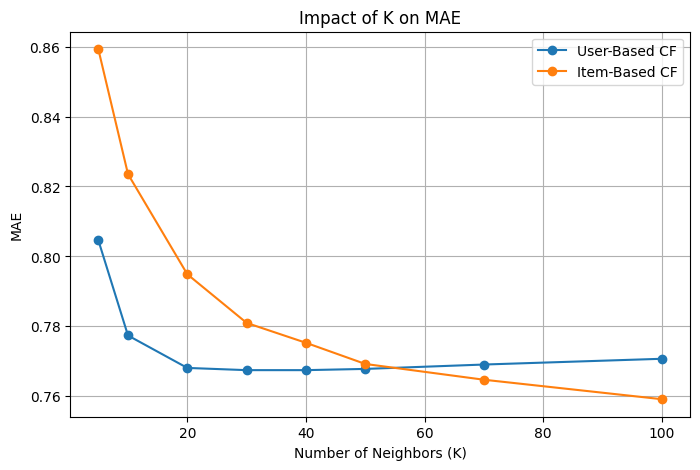


===== Part (g): Best K by RMSE =====
Best K for User-Based CF : 70, RMSE = 0.9931
Best K for Item-Based CF : 100, RMSE = 0.9780
The best K is different for User-Based CF and Item-Based CF.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate

ratings = pd.read_csv("ratings_small.csv") #Part (a)

print("First 5 rows:")
print(ratings.head())

print("\nColumns:")
print(ratings.columns)

ratings_data = ratings[["userId", "movieId", "rating"]]

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_data, reader)

def evaluate_model(algo, data, model_name):
    results = cross_validate(
        algo,
        data,
        measures=["RMSE", "MAE"],
        cv=5,
        verbose=False
    )

    avg_rmse = np.mean(results["test_rmse"])
    avg_mae = np.mean(results["test_mae"])

    print(f"\n{model_name}")
    print(f"Average RMSE: {avg_rmse:.4f}")
    print(f"Average MAE : {avg_mae:.4f}")

    return avg_rmse, avg_mae

pmf_model = SVD(biased=False, random_state=42) #Part (c)

user_cf_model = KNNBasic( #User-based CF
    sim_options={
        "name": "cosine",
        "user_based": True
    }
)

item_cf_model = KNNBasic( #Item-based CF
    sim_options={
        "name": "cosine",
        "user_based": False
    }
)

print("===== Part (c): 5-Fold Cross Validation =====")
pmf_rmse, pmf_mae = evaluate_model(pmf_model, data, "PMF / Matrix Factorization")
user_rmse, user_mae = evaluate_model(user_cf_model, data, "User-Based CF")
item_rmse, item_mae = evaluate_model(item_cf_model, data, "Item-Based CF")

comparison_df = pd.DataFrame({ #Part (d)
    "Model": ["PMF", "User-Based CF", "Item-Based CF"],
    "Average RMSE": [pmf_rmse, user_rmse, item_rmse],
    "Average MAE": [pmf_mae, user_mae, item_mae]
})

print("\n===== Part (d): Model Comparison =====")
print(comparison_df)

best_rmse_model = comparison_df.loc[comparison_df["Average RMSE"].idxmin(), "Model"]
best_mae_model = comparison_df.loc[comparison_df["Average MAE"].idxmin(), "Model"]

print(f"\nBest model by RMSE: {best_rmse_model}")
print(f"Best model by MAE : {best_mae_model}")

similarity_metrics = ["cosine", "msd", "pearson"] #Part (e)

user_sim_results = {"Similarity": [], "RMSE": [], "MAE": []}
item_sim_results = {"Similarity": [], "RMSE": [], "MAE": []}

print("\n===== Part (e): Similarity Comparison =====")

for sim in similarity_metrics:

    user_algo = KNNBasic(
        sim_options={
            "name": sim,
            "user_based": True
        }
    )
    u_rmse, u_mae = evaluate_model(user_algo, data, f"User-Based CF ({sim})")
    user_sim_results["Similarity"].append(sim)
    user_sim_results["RMSE"].append(u_rmse)
    user_sim_results["MAE"].append(u_mae)

    item_algo = KNNBasic(
        sim_options={
            "name": sim,
            "user_based": False
        }
    )
    i_rmse, i_mae = evaluate_model(item_algo, data, f"Item-Based CF ({sim})")
    item_sim_results["Similarity"].append(sim)
    item_sim_results["RMSE"].append(i_rmse)
    item_sim_results["MAE"].append(i_mae)

user_sim_df = pd.DataFrame(user_sim_results)
item_sim_df = pd.DataFrame(item_sim_results)

print("\nUser-Based CF Similarity Results:")
print(user_sim_df)

print("\nItem-Based CF Similarity Results:")
print(item_sim_df)

#Plot1 RMSE
plt.figure(figsize=(8, 5))
plt.plot(user_sim_df["Similarity"], user_sim_df["RMSE"], marker="o", label="User-Based CF")
plt.plot(item_sim_df["Similarity"], item_sim_df["RMSE"], marker="o", label="Item-Based CF")
plt.xlabel("Similarity Metric")
plt.ylabel("RMSE")
plt.title("Impact of Similarity Metric on RMSE")
plt.legend()
plt.grid(True)
plt.show()

#Plot2 MAE
plt.figure(figsize=(8, 5))
plt.plot(user_sim_df["Similarity"], user_sim_df["MAE"], marker="o", label="User-Based CF")
plt.plot(item_sim_df["Similarity"], item_sim_df["MAE"], marker="o", label="Item-Based CF")
plt.xlabel("Similarity Metric")
plt.ylabel("MAE")
plt.title("Impact of Similarity Metric on MAE")
plt.legend()
plt.grid(True)
plt.show()

k_values = [5, 10, 20, 30, 40, 50, 70, 100] #Part (f)

user_k_results = {"K": [], "RMSE": [], "MAE": []}
item_k_results = {"K": [], "RMSE": [], "MAE": []}

print("\n===== Part (f): Number of Neighbors (K) =====")

for k in k_values:
    # User-based CF
    user_algo = KNNBasic(
        k=k,
        sim_options={
            "name": "cosine",
            "user_based": True
        }
    )
    u_rmse, u_mae = evaluate_model(user_algo, data, f"User-Based CF (K={k})")
    user_k_results["K"].append(k)
    user_k_results["RMSE"].append(u_rmse)
    user_k_results["MAE"].append(u_mae)

    # Item-based CF
    item_algo = KNNBasic(
        k=k,
        sim_options={
            "name": "cosine",
            "user_based": False
        }
    )
    i_rmse, i_mae = evaluate_model(item_algo, data, f"Item-Based CF (K={k})")
    item_k_results["K"].append(k)
    item_k_results["RMSE"].append(i_rmse)
    item_k_results["MAE"].append(i_mae)

user_k_df = pd.DataFrame(user_k_results)
item_k_df = pd.DataFrame(item_k_results)

print("\nUser-Based CF K Results:")
print(user_k_df)

print("\nItem-Based CF K Results:")
print(item_k_df)

#Plot1 RMSE vs K
plt.figure(figsize=(8, 5))
plt.plot(user_k_df["K"], user_k_df["RMSE"], marker="o", label="User-Based CF")
plt.plot(item_k_df["K"], item_k_df["RMSE"], marker="o", label="Item-Based CF")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("Impact of K on RMSE")
plt.legend()
plt.grid(True)
plt.show()

#Plot2 MAE vs K
plt.figure(figsize=(8, 5))
plt.plot(user_k_df["K"], user_k_df["MAE"], marker="o", label="User-Based CF")
plt.plot(item_k_df["K"], item_k_df["MAE"], marker="o", label="Item-Based CF")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAE")
plt.title("Impact of K on MAE")
plt.legend()
plt.grid(True)
plt.show()

best_user_k_row = user_k_df.loc[user_k_df["RMSE"].idxmin()] #Part (g)
best_item_k_row = item_k_df.loc[item_k_df["RMSE"].idxmin()]

print("\n===== Part (g): Best K by RMSE =====")
print(f"Best K for User-Based CF : {int(best_user_k_row['K'])}, RMSE = {best_user_k_row['RMSE']:.4f}")
print(f"Best K for Item-Based CF : {int(best_item_k_row['K'])}, RMSE = {best_item_k_row['RMSE']:.4f}")

if int(best_user_k_row["K"]) == int(best_item_k_row["K"]):
    print("The best K is the same for both User-Based CF and Item-Based CF.")
else:
    print("The best K is different for User-Based CF and Item-Based CF.")